# Model in this notebook

We solve a one-period sovereign debt model with exogenous IMF lending policy. The IMF loan is given by a state-dependent rule `l(g, eps)` at gross rate `R_l`. The government chooses next-period private debt `b'` (via issuance `n`) and can default.

**Repayment value:**

$$
v^{nd}(b,g,\epsilon) = \max_{c,n} \left\{ \frac{c^{1-\gamma}}{1-\gamma} + \beta g^{1-\gamma} E\left[\max\{v^{nd}(b',g',\epsilon'), v^{d}(b',g',\epsilon')\} \mid g\right] \right\}\
$$

$$
c + b = y + n + (1-R_l)l(g,\epsilon),\quad g b' = R(n,g) n,\quad y = g e^{\sigma\epsilon}.
$$

**Default value:**

$$
v^{d}(b,g,\epsilon) = \frac{(\phi(g) y)^{1-\gamma}}{1-\gamma} + \beta g^{1-\gamma} E\left[ \theta v^{d}(b',g',\epsilon') + (1-\theta) \max\{v^{nd}(\kappa b',g',\epsilon'), v^{d}(b',g',\epsilon')\} \mid g \right],
$$
$$
g b' = b.
$$
Prices follow `Q(b,g,eps) = (1-d) + d X` with `X` defined by the recovery equation, and `R(n,g)` is obtained from the pricing schedule.

In [1]:
using LinearAlgebra, Statistics
include("src/structs.jl")
include("src/utils.jl")
include("src/solver.jl")
include("src/simulation.jl")


summarize_simulation (generic function with 1 method)

In [2]:
# Initialize model with default parameters and grids
model = init_model()


Model(1000, 2, 10, -0.05, 1.0, [-0.05, -0.048948948948948946, -0.0478978978978979, -0.04684684684684685, -0.0457957957957958, -0.04474474474474475, -0.04369369369369369, -0.04264264264264264, -0.04159159159159159, -0.04054054054054054  …  0.9905405405405405, 0.9915915915915916, 0.9926426426426427, 0.9936936936936936, 0.9947447447447447, 0.9957957957957958, 0.9968468468468469, 0.9978978978978978, 0.9989489489489489, 1.0], [0.96, 1.04], [-2.5, -1.9444444444444444, -1.3888888888888888, -0.8333333333333334, -0.2777777777777778, 0.2777777777777778, 0.8333333333333334, 1.3888888888888888, 1.9444444444444444, 2.5], [0.6 0.4; 0.25 0.75], [0.013134145691021127, 0.034656206581793615, 0.08546991062969068, 0.15599709785146645, 0.2107426392460281, 0.2107426392460281, 0.1559970978514664, 0.08546991062969073, 0.03465620658179361, 0.013134145691021124], 0.55, 2.0, 0.023, 2.5, 0.01, 0.1, 0.75, [0.985, 0.9], [1.0, 1.0], 1.02, 0.0, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], 0.65, 200, 200, 2000, 1.0e-6, 1.0

In [3]:
include(normpath(joinpath(pwd(), "..", "jld2_io.jl")))

start_mode = :fortran  # :fortran or :saved
cache_path = joinpath(pwd(), "results", "solution.jld2")
guess_sol = start_mode == :saved && isfile(cache_path) ? load_jld2_file(cache_path).sol : fortran_initial_guess(model)

sol = solve_model(model; sol = guess_sol)
mean(sol.d)


0.37955

In [4]:
# Diagnostics: iteration counts, errors, and per-iteration timing
println("Outer iterations: ", sol.outer_iters)
println("Final outer error: ", sol.outer_errs[end])

for i in 1:sol.outer_iters
    println("iter=", i,
        ", vnd_err=", sol.outer_errs[i],
        ", vd_err=", sol.vd_errs[i],
        ", x_err=", sol.x_errs[i],
        ", vd_iters=", sol.vd_iters[i],
        ", x_iters=", sol.x_iters[i],
        ", time_s=", sol.outer_times[i])
end


Outer iterations: 65
Final outer error: 6.567370056664856e-7
iter=1, vnd_err=0.6370022313932666, vd_err=2.3053598852129653e-7, x_err=5.711177256673139e-7, vd_iters=7, x_iters=8, time_s=0.6726911067962646
iter=2, vnd_err=0.21148158954372187, vd_err=1.2975946717119768e-7, x_err=7.747553628645321e-7, vd_iters=6, x_iters=19, time_s=0.1003580093383789
iter=3, vnd_err=0.05423516804382178, vd_err=4.335865879667722e-7, x_err=7.666117742832768e-7, vd_iters=5, x_iters=29, time_s=0.15131592750549316
iter=4, vnd_err=0.03203617192063701, vd_err=6.489635229200985e-7, x_err=3.739006746439344e-7, vd_iters=10, x_iters=15, time_s=0.14252591133117676
iter=5, vnd_err=0.04766292962871388, vd_err=7.332415559169192e-7, x_err=8.971506474386715e-7, vd_iters=9, x_iters=42, time_s=0.09826016426086426
iter=6, vnd_err=0.03354533041897634, vd_err=7.454810786455823e-7, x_err=6.957535521046054e-7, vd_iters=9, x_iters=19, time_s=0.08777785301208496
iter=7, vnd_err=0.042311065281729565, vd_err=6.730434227719684e-7, x_e

In [5]:
# sol = solve_model(model; sol = sol)    # reuse vnd/vd if non-empty
# mean(sol.d)

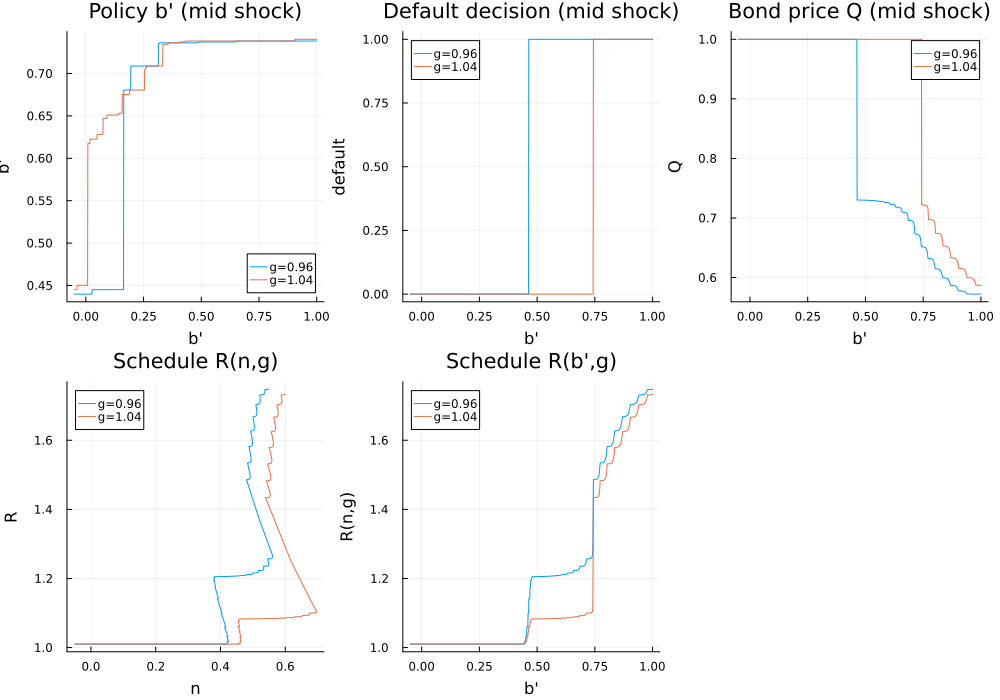

In [6]:
using Plots
b = model.b
g = model.g
eps = model.eps
e_idx = Int(cld(model.Ne, 2))
p1 = plot(title = "Policy b' (mid shock)", xlabel = "b'", ylabel = "b'")
p2 = plot(title = "Default decision (mid shock)", xlabel = "b'", ylabel = "default")
p3 = plot(title = "Bond price Q (mid shock)", xlabel = "b'", ylabel = "Q")
p4 = plot(title = "Schedule R(n,g)", xlabel = "n", ylabel = "R")
p5 = plot(title = "Schedule R(b',g)", xlabel = "b'", ylabel = "R(n,g)")
for gi in 1:model.Ng
    bprime_policy = b[sol.b_policy_idx[:, gi, e_idx]]
    plot!(p1, b, bprime_policy, label = "g=$(g[gi])")
    plot!(p2, b, Float64.(sol.d[:, gi, e_idx]), label = "g=$(g[gi])")
    plot!(p3, b, sol.Q[:, gi, e_idx], label = "g=$(g[gi])")
    plot!(p4, sol.n[:, gi], sol.R[:, gi], label = "g=$(g[gi])")
    plot!(p5, b, sol.R[:, gi], label = "g=$(g[gi])")
end
plot(p1, p2, p3, p4, p5, layout = (2, 3), size = (1000, 700))


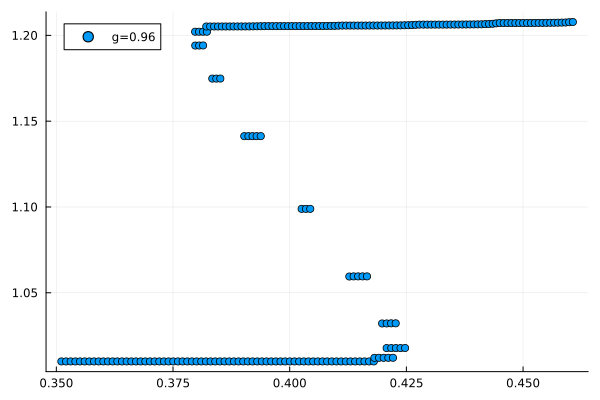

In [7]:
st = 400 #1550
en = 600
gi = 1
plot(sol.n[st:en, gi], sol.R[st:en, gi], label = "g=$(g[gi])", seriestype=:scatter)

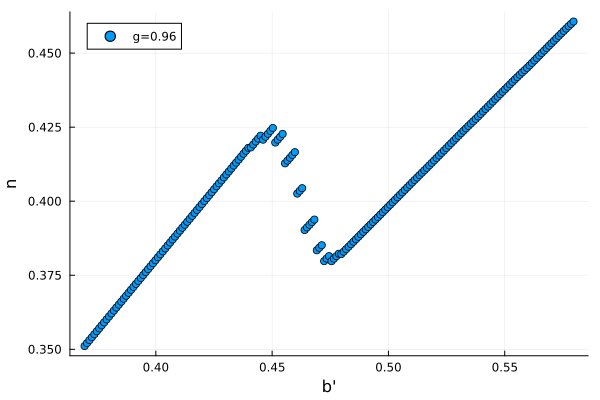

In [8]:
st = 400 #1550
en = 600
plot(b[st:en],sol.n[st:en,1] , label="g=0.96", xlabel="b'", ylabel="n", seriestype=:scatter)


In [9]:
# Simulation
b0_idx = 1  # pick a savings grid point by index
sim = simulate(model, sol; T = 200_000, b0_idx = b0_idx, seed = 1234)


(b = [-0.05, 0.4397897897897898, 0.7361861861861861, 0.5753753753753754, 0.7382882882882883, 0.7382882882882883, 0.7382882882882883, 0.5764264264264264, 0.7382882882882883, 0.7382882882882883  …  0.7382882882882883, 0.7382882882882883, 0.7687687687687688, 0.8003003003003003, 0.6247747747747747, 0.7382882882882883, 0.7382882882882883, 0.7687687687687688, 0.8003003003003003, 0.8339339339339339], y = [0.9538862176008525, 0.978577465326334, 0.9395779243368396, 1.060125587436862, 1.0202564798148663, 1.0466657150274226, 0.9158707043065294, 1.0466657150274226, 1.0466657150274226, 0.9638988033464391  …  1.1015526814809216, 0.9516606732018565, 0.9276485839547476, 0.976294312936924, 1.033376735734257, 1.0202564798148663, 0.988849225835593, 0.9638988033464391, 0.9516606732018565, 0.976294312936924], n = [0.41801801801801797, 0.5604771515811193, 0.0, 0.696700966057615, 0.696700966057615, 0.696700966057615, 0.0, 0.696700966057615, 0.696700966057615, 0.0  …  0.696700966057615, 0.0, 0.0, 0.0, 0.69670

In [10]:
# Moments
stats = summarize_simulation(sim, model; burnin = 10_000, nbins = 1000)

println("Default rate (episodes / periods): ", stats.default_rate)
println("Mean debt-to-GDP: ", stats.mean_b_to_gdp)
println("Mean issuance-to-GDP: ", stats.mean_n_to_gdp)
println("Mean credit spread (non-default): ", stats.mean_credit_spread, " (N=", stats.credit_spread_obs, ")")
println("Share at b_min: ", stats.share_b_min, ", share at b_max: ", stats.share_b_max)

stats.hist_edges
stats.hist_counts


Default rate (episodes / periods): 0.14906842105263157
Mean debt-to-GDP: 0.7418385823904712
Mean issuance-to-GDP: 0.39667206988644643
Mean credit spread (non-default): 0.09212316604041305 (N=112485)
Share at b_min: 0.0, share at b_max: 0.008026315789473683


1000-element Vector{Int64}:
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    ⋮
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
 1525

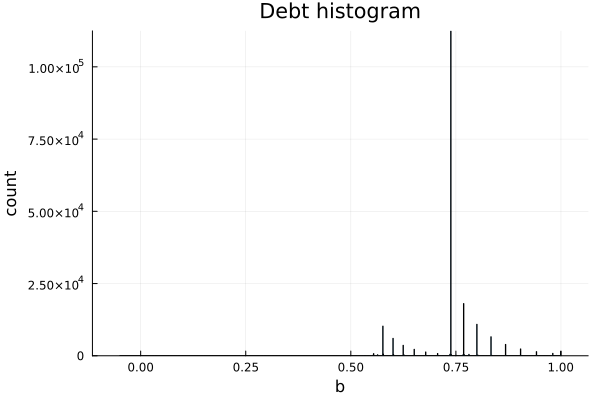

In [11]:
# Histogram of debt (b)
edges = stats.hist_edges
counts = stats.hist_counts
mid = 0.5 .* (edges[1:end-1] .+ edges[2:end])
bar(mid, counts; xlabel = "b", ylabel = "count", legend = false, title = "Debt histogram")


In [12]:
include(normpath(joinpath(pwd(), "..", "jld2_io.jl")))

results_dir = joinpath(pwd(), "results")
mkpath(results_dir)

fpath = joinpath(results_dir, "solution.jld2")
save_jld2_file(fpath; model = model, sol = sol, metadata = (format = "baseline_model_solution_v1",))
println("saved " , fpath)


saved /Users/erfanahar/Dropbox/Research/Sovereign Debt and Stagnation/1period/results/solution.jld2
